# scRITMO: Finding Rhythmic Genes with Harmonic GLM Regression

The other tutorials seed the model from a fixed reference gene set (the Zhang core-clock genes, or
one built from GEO data). This notebook shows where a reference table like that can come from in
the first place: fitting a harmonic regression against a **known** external time with
`scritmo.glm.glm_gene_fit`, gene by gene, across the whole transcriptome.

We reuse the same skin dataset as [`tutorial_inference.ipynb`](tutorial_inference.ipynb) (known ZT
time labels), restricted to fibroblasts — the dominant cell type — so the regression is fit on a
single, homogeneous population.

The output, `glm_gene_fit`'s fitted `Beta` table, is exactly the shape `params_g` needs to be for
phase inference (`a_0`, `a_1`, `b_1`, `disp`, ...) — so this is also how you'd build your own
`params_g` from a new time-course dataset, to hand to `cr.warmup_and_train` as in the other
tutorials. This notebook stops at the fit itself and a look at the discovered genes.

---
**Pipeline overview:**
1. Load the data
2. Genome-wide harmonic regression (`glm_gene_fit`) against the known ZT time
3. Select the significantly rhythmic genes
4. Plot expression vs. external time for the top hits, with the fitted curve


In [1]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

import scritmo as sr

%load_ext autoreload
%autoreload 2


## 1. Load the data

Same file as [`tutorial_inference.ipynb`](tutorial_inference.ipynb): mouse skin scRNA-seq sampled
across 6 ZT time points. We restrict to fibroblasts, the dominant cell type, and drop genes that
are essentially unexpressed — the GLM has nothing to fit for them and they only add noise (and
runtime) to the genome-wide screen.

`adata` already ships a total-count-normalized, **non-logged** layer, `"s_norm"` — the scale we
want on the y-axis below.


In [2]:
data_path = "/home/maxine/Documents/andrea/context_repo/data/SKIN/concatenated.h5ad"

adata = sc.read_h5ad(data_path)
adata = adata[adata.obs.celltype == "Fibroblast"].copy()
sc.pp.filter_genes(adata, min_cells=100)

true_phase = adata.obs.ZTmod.values * 2 * np.pi / 24

adata


AnnData object with n_obs × n_vars = 11446 × 14766
    obs: 'n_counts', 'sample_name', 'ZT', 'ZTmod', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 's_counts', 'u_counts', 'percent_unspliced', 'organ', 'celltype', 'celltype_organ'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'log1p'
    layers: 'ambiguous', 's_log', 's_norm', 'spliced', 'u_log', 'u_norm', 'unspliced'

## 2. Genome-wide harmonic regression

`glm_gene_fit` fits a single-harmonic Negative Binomial GLM per gene against `true_phase`, plus a
null (mean-only) model, and reports the amplitude, acrophase, and a likelihood-ratio p-value for
each gene.

We fit directly on the `"s_norm"` layer with `counts=1` (no extra per-cell offset): `s_norm` is
already size-factor normalized, so there is no separate library size left to correct for, and the
fitted `a_0`/amplitude end up on the exact same scale as the data we're about to plot. Everything
else is left at its default (`n_harmonics=1`, `noise_model="nb"`, ...).


In [3]:
params_g_full = sr.glm_gene_fit(
    adata,
    phases=true_phase,
    layer="s_norm",
    counts=np.ones(adata.n_obs),
)
params_g_full.shape


Running in parallel on -1 jobs.


(11626, 13)

## 3. Select the rhythmic genes

`Beta.quick_filtering()` keeps genes with a sizeable amplitude (`log2fc >= 0.8`), a reasonably
expressed baseline, and a significant harmonic fit (BH-corrected p-value <= 0.05) — all at their
default thresholds.

The top hits by amplitude are, reassuringly, the core clock genes themselves (`Dbp`, `Nr1d1`,
`Bmal1`, `Hlf`, `Ciart`, ...) even though nothing about the core clock was given to the model — they
simply have the largest, most significant oscillations in the data.


In [4]:
rhythmic = params_g_full.quick_filtering()
print(f"{len(rhythmic)} rhythmic genes out of {len(params_g_full)} tested")

rhythmic.sort_values("log2fc", ascending=False).head(15)[
    ["a_0", "amp", "phase", "log2fc", "pvalue_correctedBH", "r2"]
]


435 rhythmic genes out of 11626 tested


,a_0,amp,phase,log2fc,pvalue_correctedBH,r2
gene,,,,,,
Ciart,-6.260477,2.618895,2.664071,7.556534,0.000000,0.139375
Dbp,-0.749993,1.778553,2.538407,5.131820,0.000000,0.297815
Nr1d1,-1.217384,1.717869,2.092301,4.956722,0.000000,0.239525
Bmal1,-2.820538,1.436003,6.013008,4.143428,0.000000,0.117153
Dgat2,-4.569727,1.350842,2.456725,3.897706,0.000000,0.070312
Hlf,-1.905153,1.272564,2.902832,3.671845,0.000000,0.125580
Npas2,-4.329351,1.172806,6.239203,3.384003,0.000000,0.059651
Gpr173,-6.304306,1.143843,1.080708,3.300433,0.003036,0.038670
Nfil3,-2.092986,1.112634,5.868495,3.210383,0.000000,0.090375


### Amplitude & acrophase overview

Same polar view used throughout the other tutorials, `Beta.plot_circular()` — here on the top 30
genes by amplitude, to keep the labels legible.


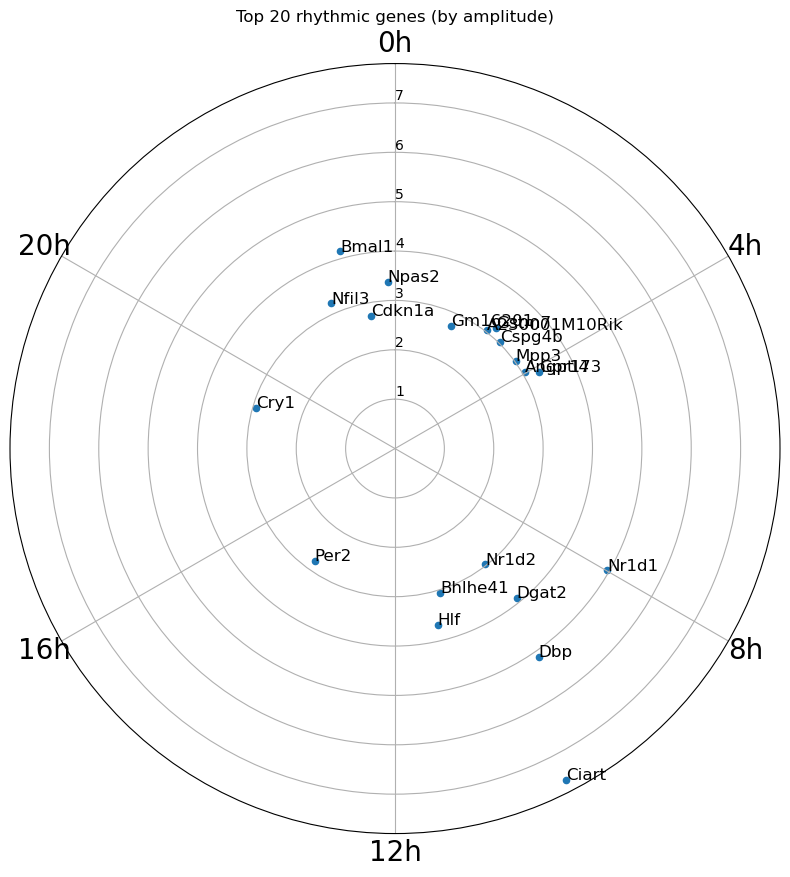

In [5]:
top_genes = rhythmic.sort_values("log2fc", ascending=False).head(20).index

rhythmic.plot_circular(
    genes_to_plot=top_genes,
    title="Top 20 rhythmic genes (by amplitude)",
    amp_lim=[0, rhythmic.loc[top_genes, "log2fc"].max() * 1.15],
    col_names=["log2fc", "phase"],
)
plt.show()


## 4. Expression vs. external time, with the fitted curve

`plot_circadian_data_and_fit` plots each cell's normalized (non-logged) expression against the
external time, plus the harmonic fit as a solid curve — the same plot a rhythmicity call ultimately
rests on.


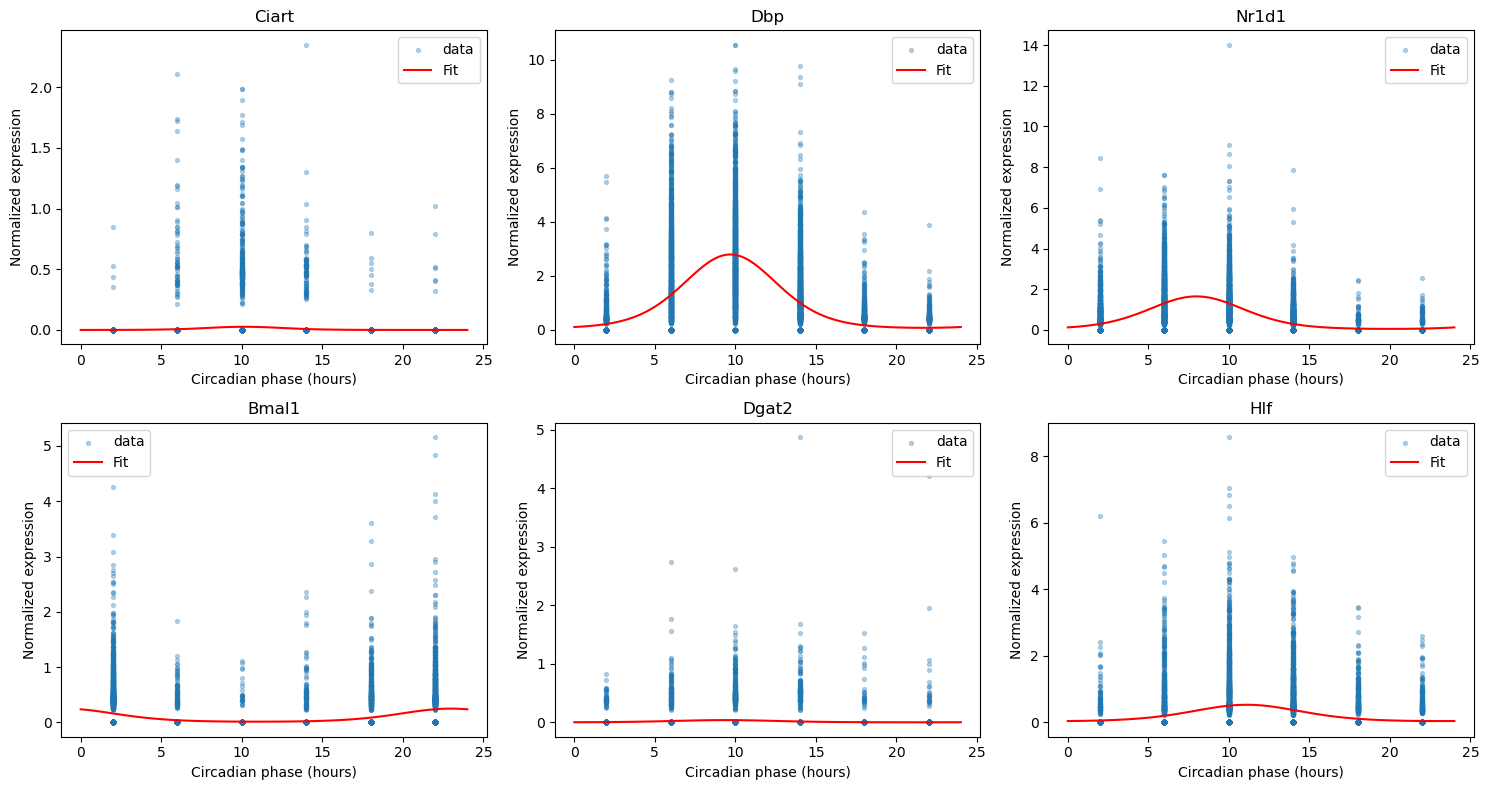

In [6]:
top6 = rhythmic.sort_values("log2fc", ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for gene, ax in zip(top6, axes.ravel()):
    sr.plot_circadian_data_and_fit(
        adata, true_phase, gene, rhythmic, layer="s_norm", ax=ax, s=8, alpha=0.3
    )
plt.tight_layout()
plt.show()


`rhythmic` is a regular `Beta` table, ready to be handed to `cr.warmup_and_train(adata, rhythmic,
...)` as `params_g` for phase inference — exactly the same pattern as the other two tutorials, just
with a reference built from this dataset's own time labels instead of borrowed from another tissue
or species.
